# Logistic Regression

## Imports

In [33]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv('../../../DATA/hearing_test.csv')

In [35]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


### Train | Test Split en Scaling

In [36]:
X = df.drop('test_result',axis=1)
y = df['test_result']

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [39]:
scaler = StandardScaler()

In [40]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Maken van het Logistic Regression Model

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
log_model = LogisticRegression()

In [43]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [44]:
log_model.coef_

array([[-0.94953524,  3.45991194]])

In [45]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


### Model Performantie voor Classificatie

In [46]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay

In [47]:
y_pred = log_model.predict(scaled_X_test)

In [48]:
# herinner de accuracy paradox: we willen niet alleen op deze metric vertrouwen!
accuracy_score(y_test,y_pred)

0.93

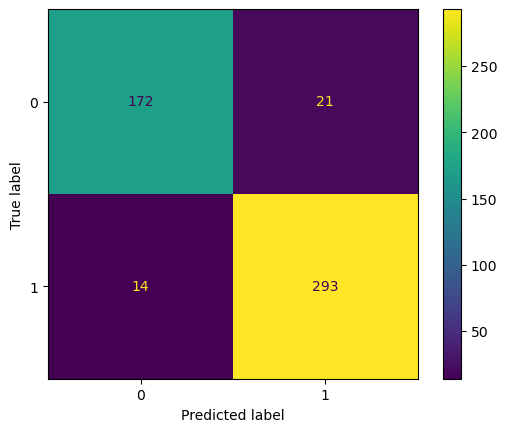

In [49]:
# Idem: confusion matrix, maar mooi geplot - Ruwe waarden
cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_model.classes_)
disp.plot()

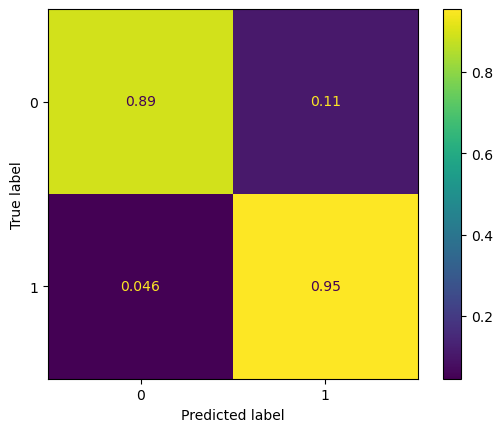

In [50]:
# Confusion matrix, genormaliseerd met normalize = true: 
# Dit is normalisatie over rijen, dus over de echte labels.  Normalisatie betekent dat de waarden in de rij
# zullen worden genormaliseerd om samen een som van 1 te bekomen (100%)

# Elke rij in de confusion matrix zal de proportie predicties voor de respectieve echte klasse weergeven.
# Dit geeft, voor elke echte klasse (0 / 1), welke proportie van de samples voor elke klasse werden voorspeld
# Concreet: de eerste rij geeft weer dat, van alle echte klasse 0 samples, 89% correct werd voorspeld, en 11% 
# foutief aan klasse 1 werden toegekend.
# De tweede rij geeft aan dat 5% van de echte klasse 1 samples foutief als klasse 0 werden voorspeld, en 95% juist.

cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_model.classes_)
disp.plot()

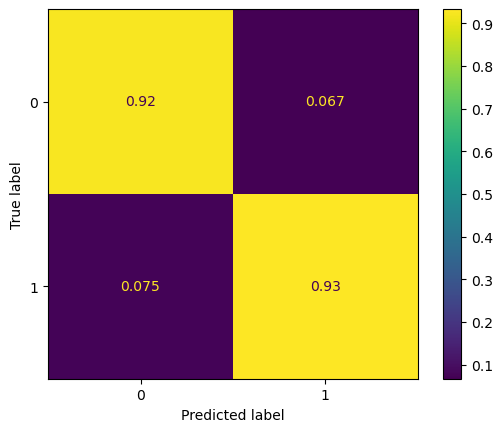

In [51]:
# Confusion matrix, genormaliseerd met normalize = pred: 
# Dit is een normalisatie op kolom, dus normalisatie zodat de som van de predicties per klasse 1 geven (dus over kolommen) 
# Concreet voor elke kolom: de waarden representeren de proportie van die voorspelde klasse die tot elke werkelijke klasse behoren.
# Maw: het leert ons, voor een gegeven voorspelde klasse, welk percentage van de voorspellingen correct waren, en welk % misclassificaties
# van andere klasses waren.

cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_, normalize='pred')

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_model.classes_)
disp.plot()

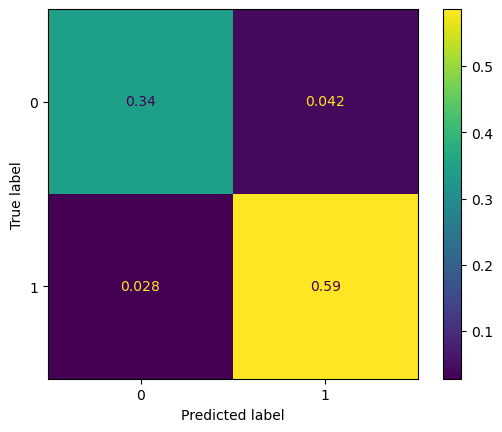

In [52]:
# Confusion matrix, genormaliseerd met normalize = all: 
# Dit is een normalisatie op totaal van de samples.  Elke waarde in de cm zal worden gedeeld door het totaal aantal
# samples om zo de proportie van het totaal weer te geven, en dus de proportie True Negatives etc...

cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_, normalize='all')

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_model.classes_)
disp.plot()

In [53]:
# Precision, Recall en F1-score:
# vergeet het print statement niet hier...
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



We krijgen precision, recall en f1-score per klasse!
recall class 1: TP / TP + FN = 293 / (293 + 14)
...
De support kolom geeft weer hoeveel instanties van elke klasse aanwezig waren in de test set om deze data te ondersteunen.  Hier zien we dat de set redelijk gebalanceerd is (193 / 307)

! Als je waarden voor precision en recall voor de individuale klasses redelijk overeenkomen met de algemene accuracy, dan is er geen probleem inzake ongebalanceerde data.

In een classification_report van sklearn, staan de termen macro avg en weighted avg voor verschillende manieren om gemiddelde scores te berekenen over de verschillende klassen. Ze zijn vooral nuttig bij multi-class classificatieproblemen. Hier is een uitleg van elk:

Macro avg (Macro Gemiddelde):
Voor elke metriek (bijv. precisie, recall, f1-score) wordt het gemiddelde berekend zonder rekening te houden met de class-imbalance (het aantal samples in elke klasse). Het behandelt elke klasse gelijk.

Weighted avg (Gewogen Gemiddelde):
Voor elke metriek wordt het gemiddelde berekend, waarbij rekening wordt gehouden met de class-imbalance. Elke klasse wordt gewogen naar het aantal daadwerkelijke samples.

vb weighted avg precision = (precisie class 1 × # samples class 1 + precisie class 2 × # samples class 2 + ...) / totaal # samples
 
De keuze voor het gebruik van macro of gewogen gemiddelde hangt af van wat je belangrijk vindt in je specifieke situatie:
-Als je wilt dat elke klasse gelijk wordt behandeld, ongeacht het aantal samples in elke klasse, gebruik dan het macro gemiddelde.
-Als je wilt dat klassen met meer samples een grotere invloed hebben op het gemiddelde, gebruik dan het gewogen gemiddelde.

In situaties met sterk onevenwichtige klassen kan het macro gemiddelde een duidelijker beeld geven van de prestaties van het model op minder voorkomende klassen, terwijl het gewogen gemiddelde een algemener beeld geeft van de algehele prestaties over het hele dataset.

### Als je enkel precision en recall wil: 

In [54]:
from sklearn.metrics import precision_score, recall_score

In [55]:
precision_score(y_test, y_pred)

0.9331210191082803

In [56]:
recall_score(y_test, y_pred)

0.9543973941368078

### Als je een voorspelling voor een punt wil

In [57]:
log_model.predict_proba(scaled_X_test)[0]

array([0.02384343, 0.97615657])

In [58]:
# werkelijke waarde
y_test[0]

1

## Evaluating Curves and AUC

**Make sure to watch the video on this!**

In [59]:
from sklearn.metrics import precision_recall_curve,PrecisionRecallDisplay,RocCurveDisplay

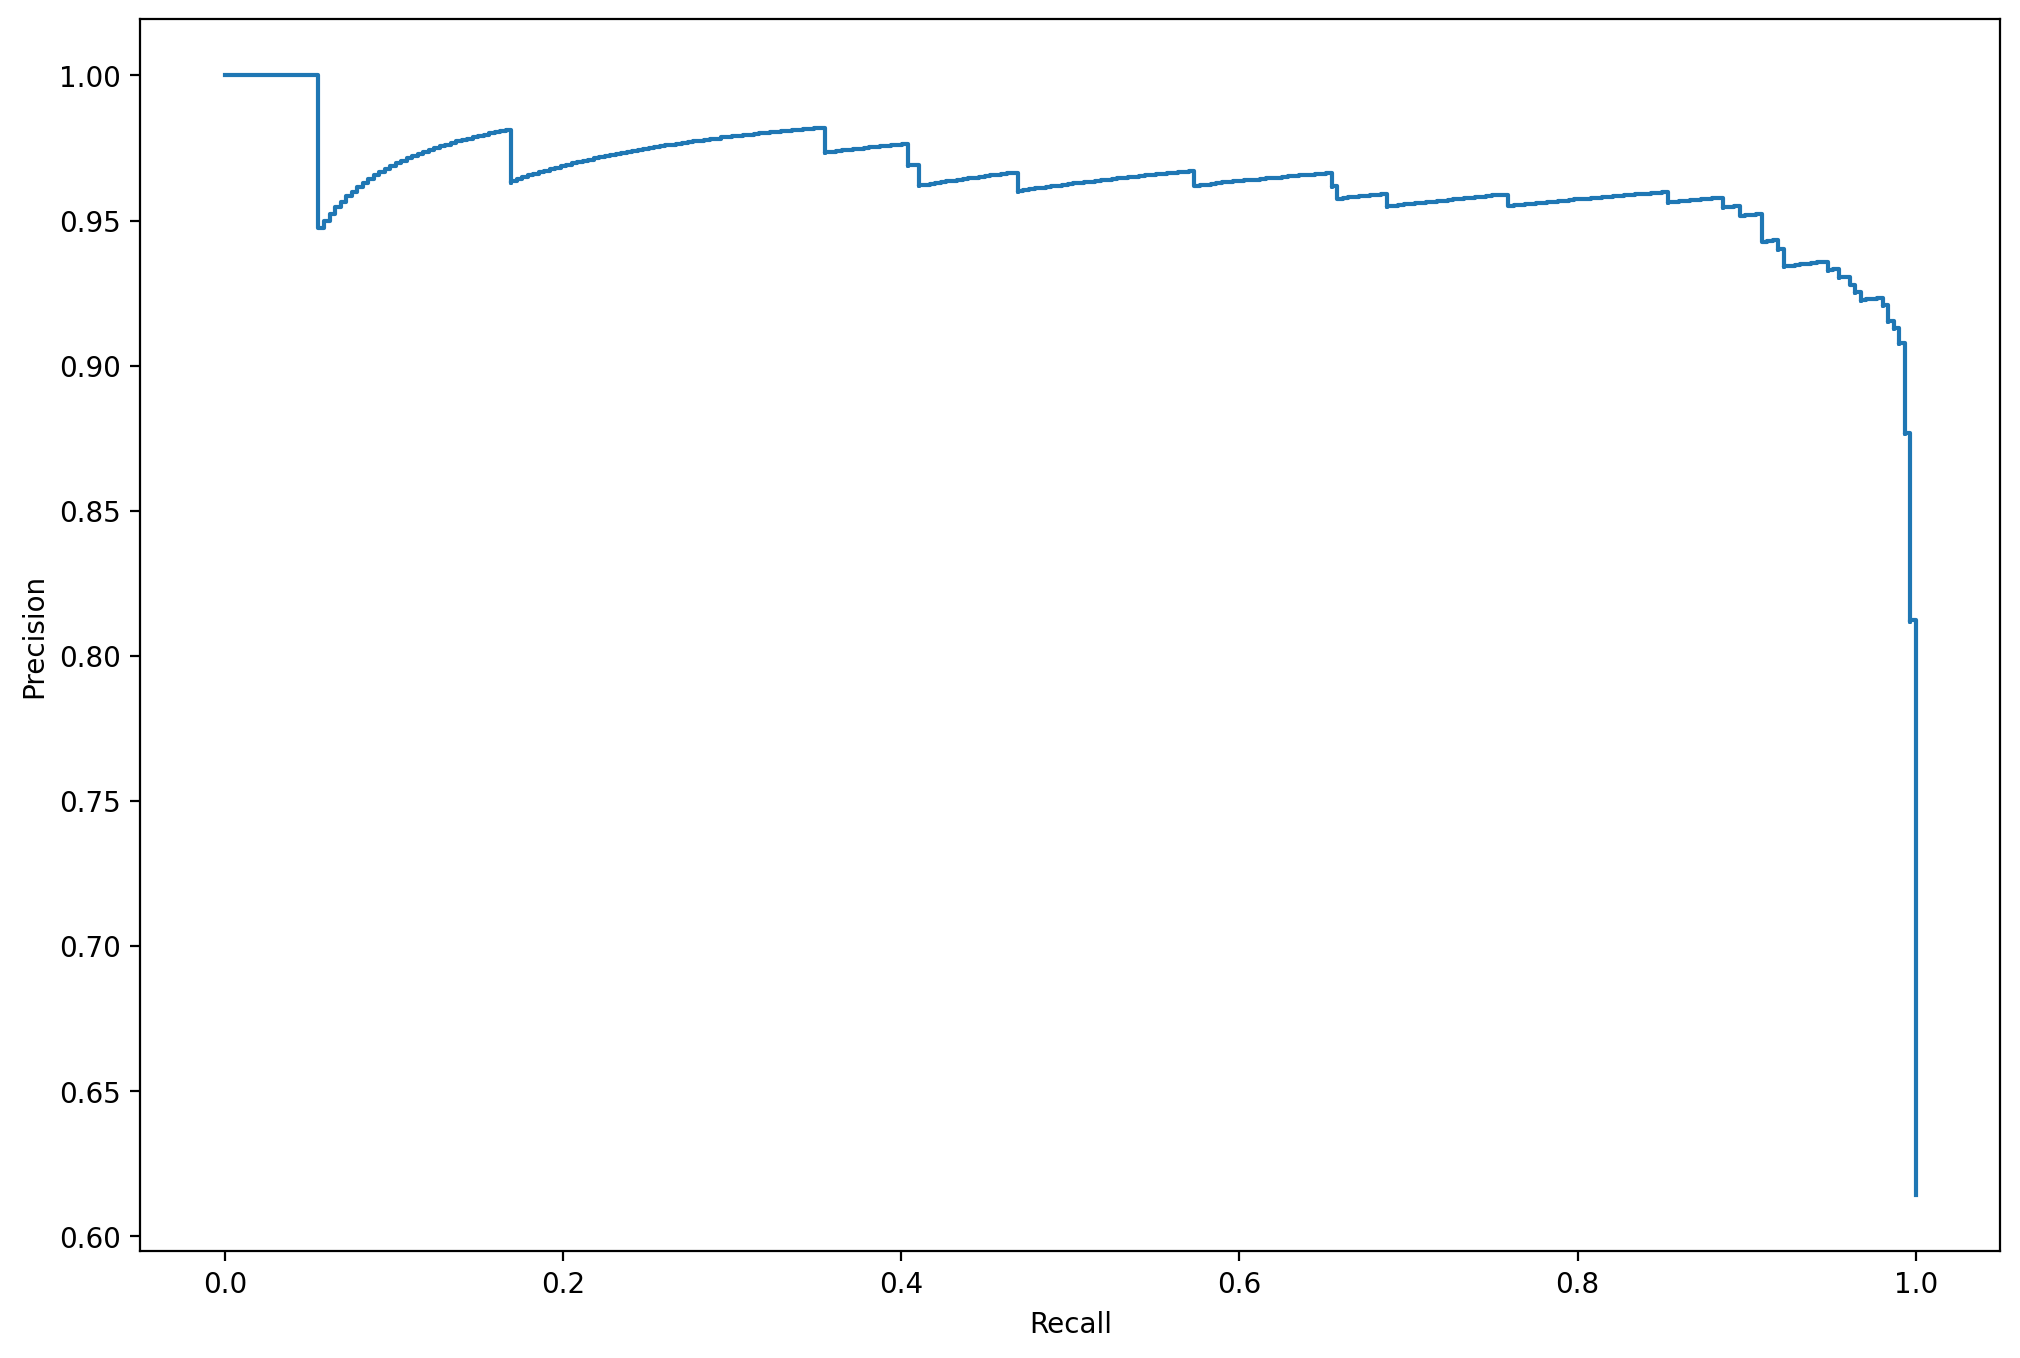

In [60]:
# tradeoff tussen precision en recall visualiseren:
fig, ax = plt.subplots(figsize=(12,8), dpi=200)
y_prob = log_model.predict_proba(scaled_X_test)
y_prob = y_prob[:,1] # enkel kans klasse 1
precision, recall, _ = precision_recall_curve(y_test, y_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot(ax=ax)

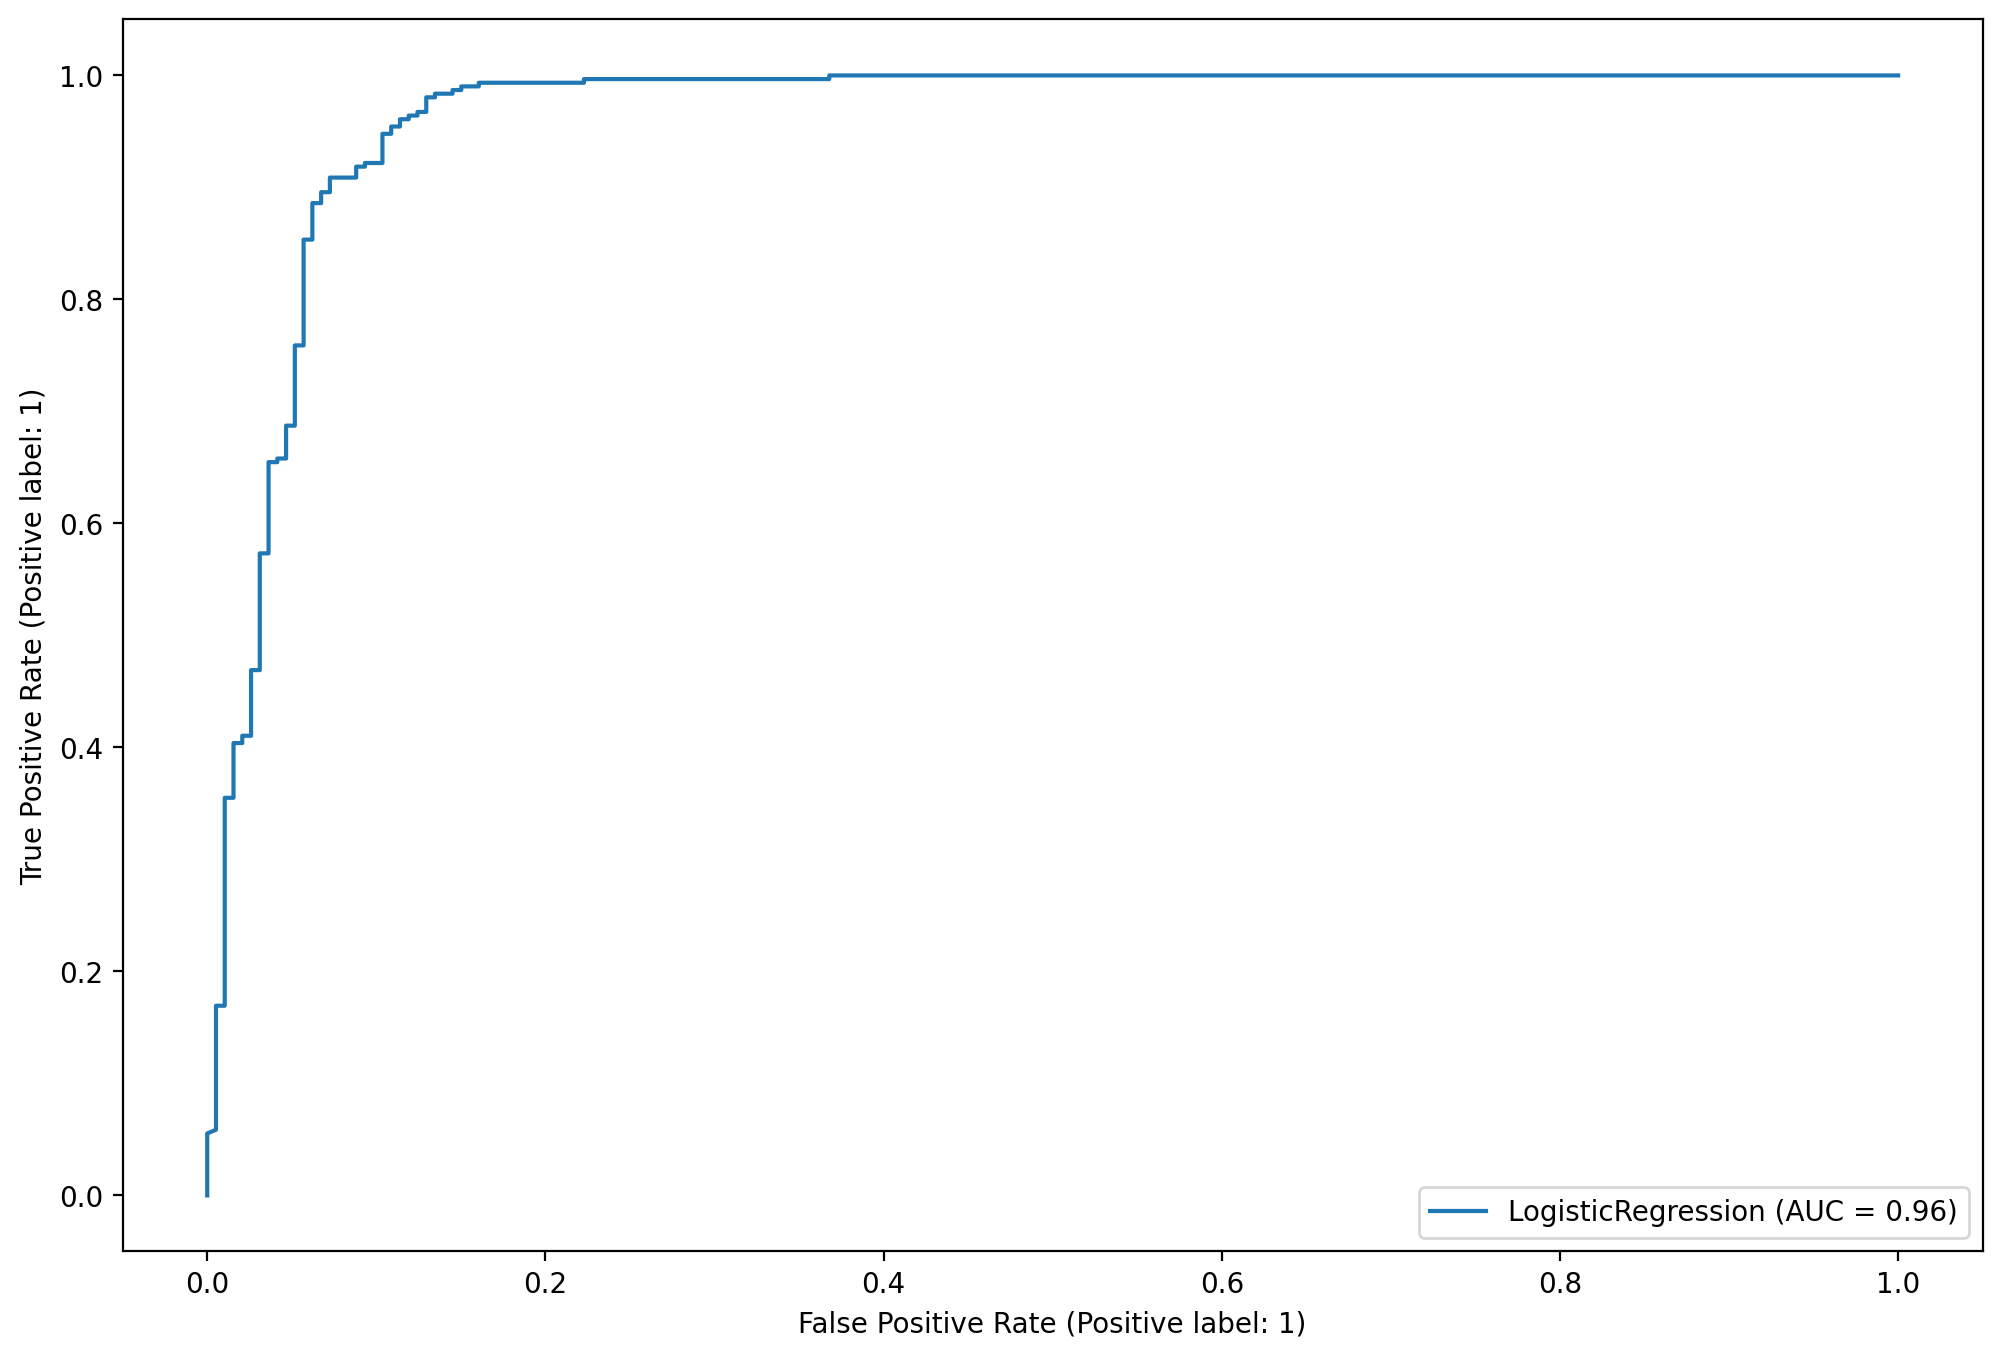

In [61]:
# ROC curve
fig, ax = plt.subplots(figsize=(12,8), dpi=200)
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test, ax=ax)

------
------